In [173]:
import pandas as pd
import numpy as np
from pathlib import Path
import ipynbname

# to get the file path
import os

#plotting library
import seaborn as sns
import matplotlib.pyplot as plt

In [174]:
#obtain the pandas df
ACTION_TYPE = "S_RPT"
ACTION_TYPE1 = "MTWR"
ACTION_TYPE2 = "A2C"


MAX_JOBS = 40
EXCEL_PATH = (Path(os.path.abspath(""))/ ".."/ ".."/ ".."/ ".." / "Archive" / rf"{ACTION_TYPE}_{MAX_JOBS}_makespan.csv").resolve()
EXCEL_PATH1 = (Path(os.path.abspath(""))/ ".."/ ".."/ ".."/ ".." / "Archive" / rf"{ACTION_TYPE1}_{MAX_JOBS}_makespan.csv").resolve()
EXCEL_PATH2 = (Path(os.path.abspath(""))/ ".."/ ".."/ ".."/ ".." / "Archive" / rf"{ACTION_TYPE2}_{MAX_JOBS}_makespan.csv").resolve()



#how to obtain file path for jupyter
df = pd.read_csv(EXCEL_PATH)
df1 = pd.read_csv(EXCEL_PATH1)
df2 = pd.read_csv(EXCEL_PATH2)



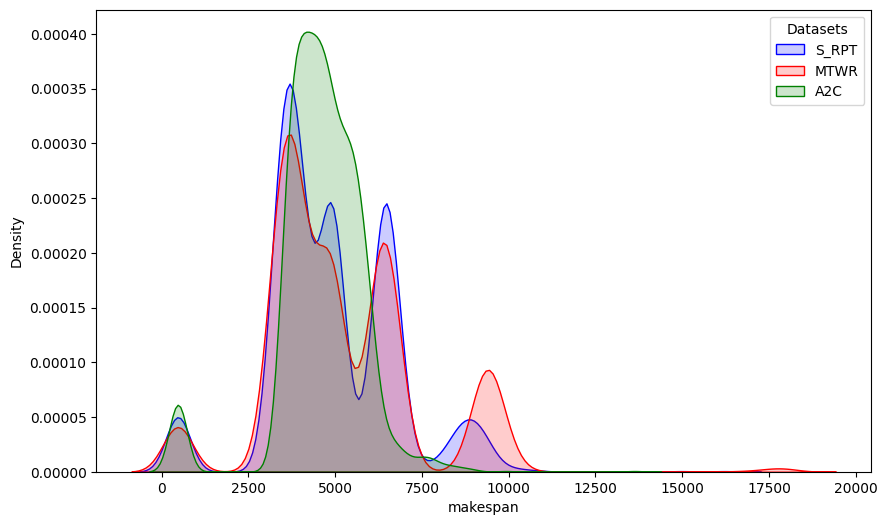

In [175]:
fig = plt.figure(figsize=(10, 6))
sns.kdeplot(df["makespan"], color="blue", label="Dataset 1", fill=True, alpha = 0.2)
sns.kdeplot(df1["makespan"], color="red", label="Dataset 2", fill=True, alpha = 0.2)
sns.kdeplot(df2["makespan"], color="green", label="Dataset 3", fill=True, alpha = 0.2)



plt.legend(["S_RPT", "MTWR", "A2C"], title="Datasets", loc="upper right")

plt.show()

In [176]:
# removing duplicates
# how to iterate rows in df
df_clean = pd.DataFrame(columns=["makespan", "makespan_count"])
for index, row in df.iterrows():
    if row["makespan"] not in df_clean["makespan"].values:
        df_clean = pd.concat([df_clean, pd.DataFrame([{"makespan": row["makespan"], "makespan_count": row["makespan_count"]}])], ignore_index=True)
    else:
        df_clean.loc[df_clean["makespan"] == row["makespan"], "makespan_count"] += row["makespan_count"]


df_clean1 = pd.DataFrame(columns=["makespan", "makespan_count"])
for index, row in df1.iterrows():
    if row["makespan"] not in df_clean1["makespan"].values:
        df_clean1 = pd.concat([df_clean1, pd.DataFrame([{"makespan": row["makespan"], "makespan_count": row["makespan_count"]}])], ignore_index=True)
    else:
        df_clean1.loc[df_clean1["makespan"] == row["makespan"], "makespan_count"] += row["makespan_count"]
    
df_clean2 = pd.DataFrame(columns=["makespan", "makespan_count"])
for index, row in df2.iterrows():
    if row["makespan"] not in df_clean2["makespan"].values:
        df_clean2 = pd.concat([df_clean2, pd.DataFrame([{"makespan": row["makespan"], "makespan_count": row["makespan_count"]}])], ignore_index=True)
    else:
        df_clean2.loc[df_clean2["makespan"] == row["makespan"], "makespan_count"] += row["makespan_count"]



<Axes: title={'center': 'Kernel Density Estimate of Makespan'}, xlabel='makespan', ylabel='makespan_count'>

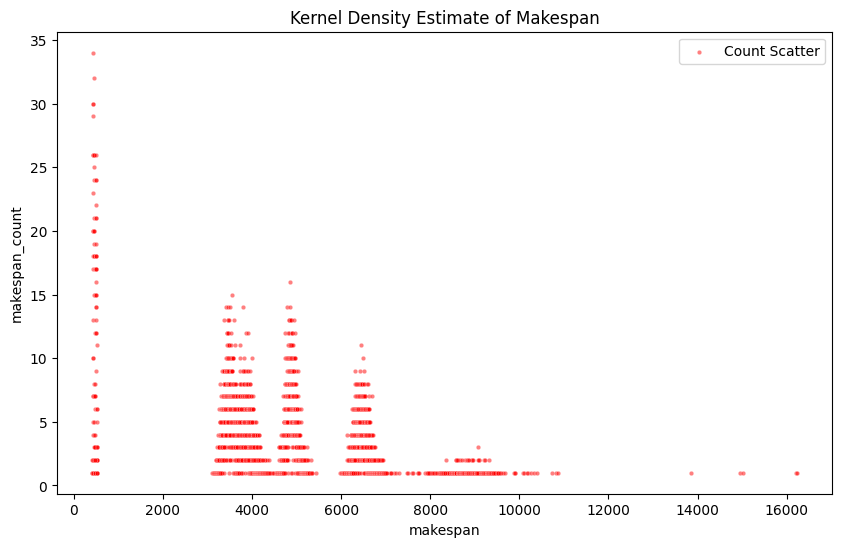

In [177]:
# how to plot count scatterplot
fig = plt.figure(figsize = (10,6))
plt.title("Kernel Density Estimate of Makespan")
sns.scatterplot(x=df_clean["makespan"], y=df_clean["makespan_count"], color="red", label="Count Scatter", alpha=0.5, s=10)

<Axes: title={'center': 'Kernel Density Estimate of Makespan'}, xlabel='makespan', ylabel='makespan_count'>

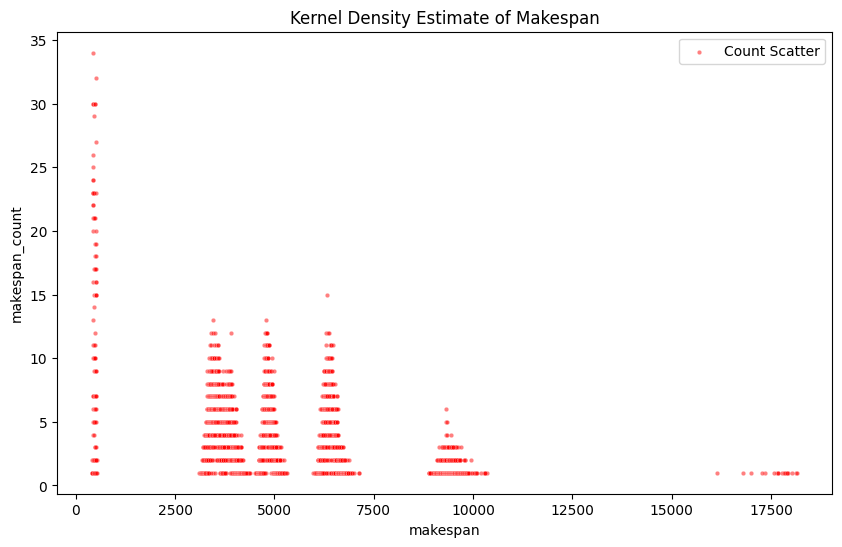

In [178]:
fig1 = plt.figure(figsize = (10,6))
plt.title("Kernel Density Estimate of Makespan")
sns.scatterplot(x=df_clean1["makespan"], y=df_clean1["makespan_count"], color="red", label="Count Scatter", alpha=0.5, s=10)

<Axes: title={'center': 'Kernel Density Estimate of Makespan'}, xlabel='makespan', ylabel='makespan_count'>

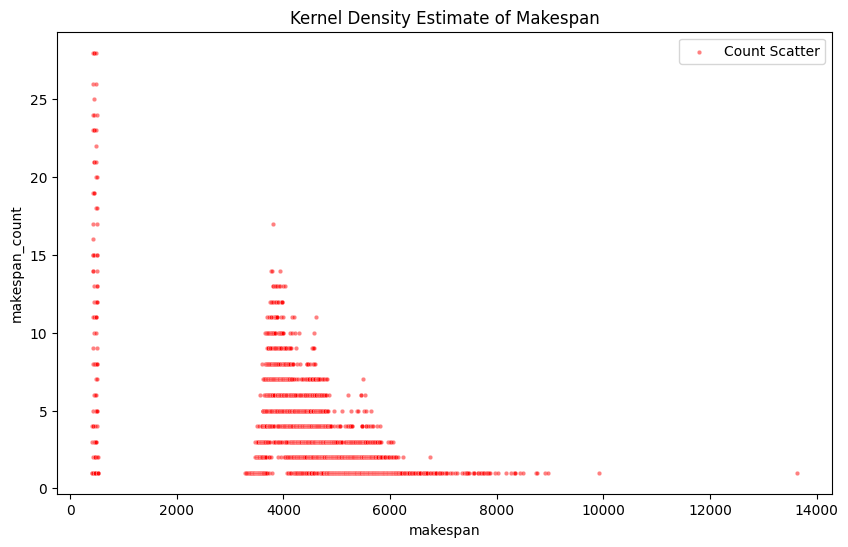

In [179]:
fig2 = plt.figure(figsize = (10,6))
plt.title("Kernel Density Estimate of Makespan")
sns.scatterplot(x=df_clean2["makespan"], y=df_clean2["makespan_count"], color="red", label="Count Scatter", alpha=0.5, s=10)

In [180]:
#cutting invalid data
df_clean = df_clean[df_clean["makespan"] > 1000]
df_clean1 = df_clean1[df_clean1["makespan"] > 1000]
df_clean2 = df_clean2[df_clean2["makespan"] > 1000]
df_clean3 = df_clean3[df_clean3["makespan"] > 1000]



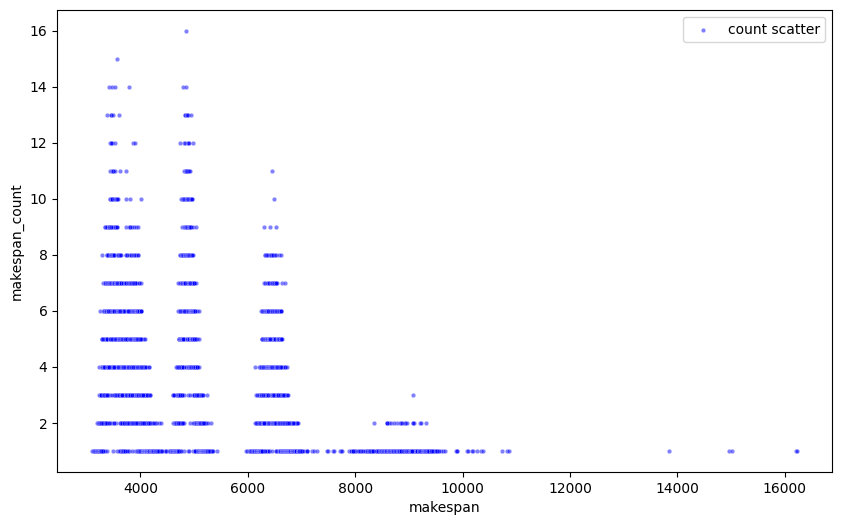

In [181]:
figtemp = plt.figure(figsize = (10,6))
sns.scatterplot(x=df_clean["makespan"], y=df_clean["makespan_count"], color = "blue", label = "count scatter", alpha=0.5, s=10)
plt.show()

In [182]:
df_clean1["makespan_count"].sum()

8812

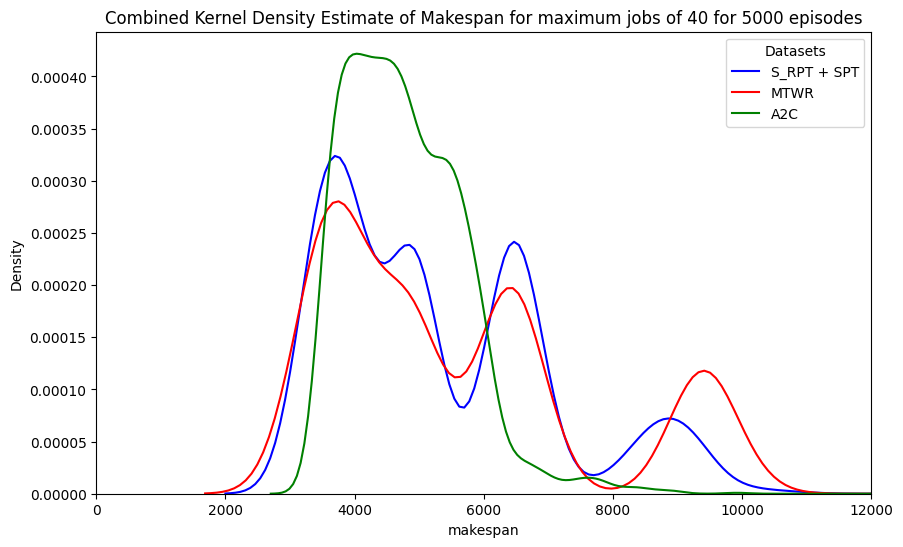

In [183]:
finalplot0 = plt.figure(figsize=(10, 6))
plt.xlim(0,12000)
plt.title(f"Combined Kernel Density Estimate of Makespan for maximum jobs of {MAX_JOBS} for 5000 episodes")
sns.kdeplot(df_clean["makespan"], color="blue", label="Dataset 2", fill=False)
sns.kdeplot(df_clean1["makespan"], color="red", label="Dataset 2", fill=False)
sns.kdeplot(df_clean2["makespan"], color="green", label="Dataset 2", fill=False)
# sns.kdeplot(df_clean3["makespan"], color="purple", label="Dataset 2", fill=False)
plt.legend(["S_RPT + SPT", "MTWR", "A2C"], title="Datasets", loc="upper right")
plt.show()
SAVE_PATH = (Path(os.path.abspath("")) / ".." / "Project" / "(FYP) Data" / "(PLOT) Makespan Adjusted" / rf"COMBINED_{MAX_JOBS}_{5000}_makespan.png").resolve()
finalplot0.savefig(SAVE_PATH)